# Modelo de árbol de decisión para para la calidad del vino

## 1. Cargar el Dataset y Librerías Necesarias

In [2]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_selection import SelectKBest, f_classif

# Cargar el dataset
file_path = 'C:/Dataset/winequality-red.csv'  # Asegúrate de que el archivo esté en la misma ubicación que el notebook
data = pd.read_csv(file_path)

# Mostrar las primeras filas del dataset
data.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 2. Análisis exploratorio de datos

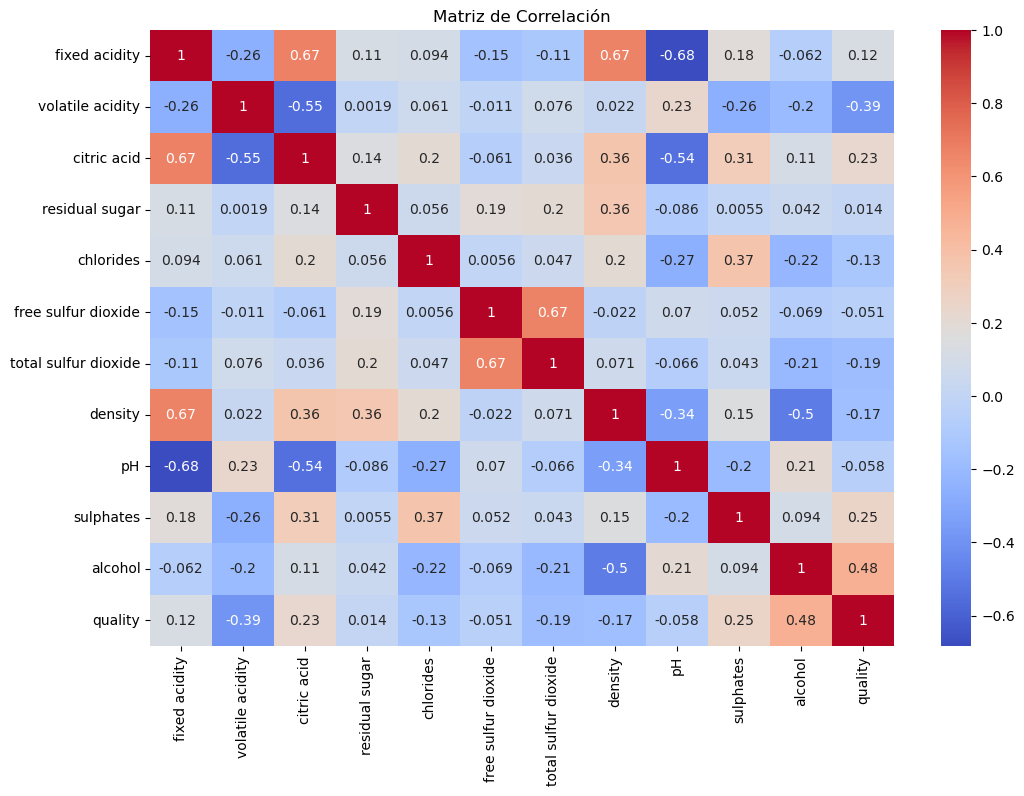

In [5]:
# Estadísticas descriptivas
data.describe()

# Verificar valores faltantes
data.isnull().sum()

# Matriz de correlación
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()


## 3. Pre procesamiento de datos

In [8]:
# Manejar valores faltantes (si los hay)
data = data.dropna()


## 4. Seleccion de caracteristicas

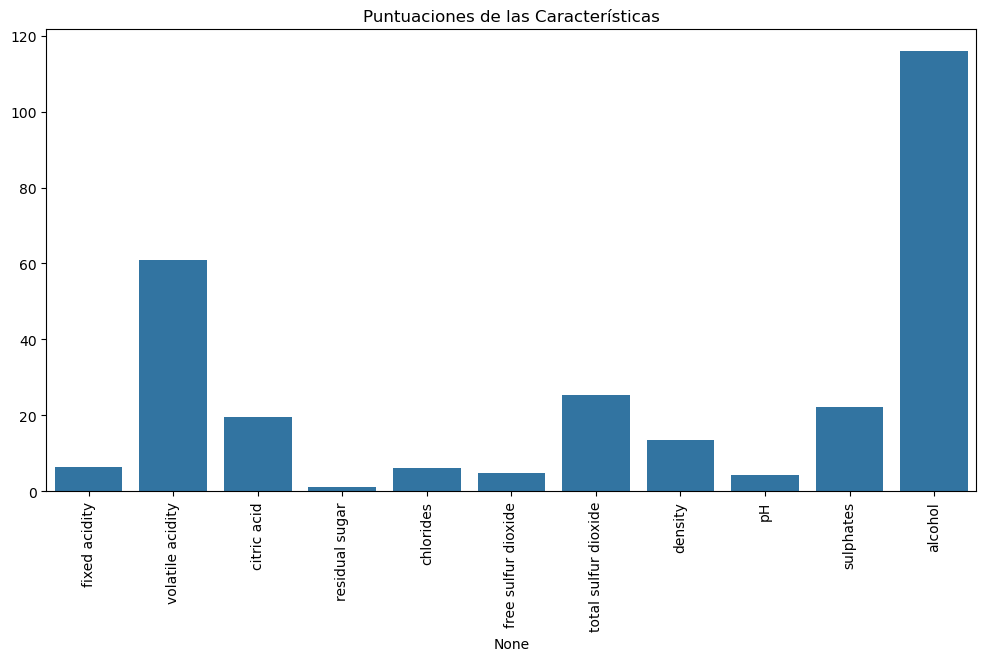

In [11]:
X = data[['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides',
          'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']]
y = data['quality']

# Seleccionar las mejores características usando ANOVA F-test
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X, y)
scores = selector.scores_

# Graficar las puntuaciones de las características
plt.figure(figsize=(12, 6))
sns.barplot(x=X.columns, y=scores)
plt.title('Puntuaciones de las Características')
plt.xticks(rotation=90)
plt.show()


## 5. Dividir el dataset en Train y Test

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## 6. Entrenar el modelo

In [17]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

## 7. Evaluar el modelo

In [20]:
y_pred = model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Accuracy Score:")
print(accuracy_score(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.63      0.68      0.65       130
           6       0.55      0.53      0.54       132
           7       0.51      0.50      0.51        42
           8       0.00      0.00      0.00         5

    accuracy                           0.56       320
   macro avg       0.28      0.28      0.28       320
weighted avg       0.55      0.56      0.55       320

Confusion Matrix:
[[ 0  0  0  1  0  0]
 [ 0  0  5  5  0  0]
 [ 1  4 88 35  2  0]
 [ 0  3 40 70 17  2]
 [ 0  1  5 14 21  1]
 [ 0  0  1  3  1  0]]
Accuracy Score:
0.559375


## 8. Visualizar los resultados

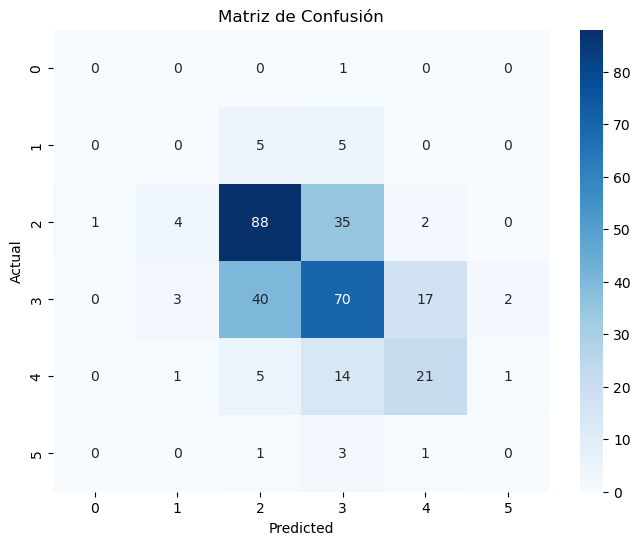

In [23]:
# Matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


## 9. Conclusiones

El modelo de árbol de decisión entrenado para predecir la calidad del vino tinto ha mostrado un desempeño moderado con una precisión global del 55.94%. A continuación, se detallan los resultados obtenidos y su interpretación:

Informe de Clasificación
Clases 3 y 4: El modelo no logró predecir correctamente las clases 3 y 4, con una precisión, recall y f1-score de 0.00. Esto puede deberse a la baja cantidad de muestras en estas clases (1 y 10 respectivamente), lo que dificulta el aprendizaje del modelo.
Clase 5: Esta clase obtuvo los mejores resultados con una precisión de 0.63 y un recall de 0.68, indicando que el modelo es relativamente bueno para identificar vinos de calidad 5.
Clase 6: Con una precisión de 0.55 y un recall de 0.53, el modelo muestra un desempeño aceptable para esta clase.
Clase 7: La precisión y el recall para esta clase son de 0.51 y 0.50 respectivamente, lo que indica un desempeño moderado.
Clase 8: Similar a las clases 3 y 4, el modelo no logró predecir correctamente la clase 8, posiblemente debido a la baja cantidad de muestras (5).
Matriz de Confusión
La matriz de confusión muestra que el modelo tiene dificultades para distinguir entre clases adyacentes, especialmente entre las clases 5 y 6, y entre las clases 6 y 7. Esto sugiere que las características del vino que determinan estas calidades son muy similares, lo que complica la tarea del modelo.

Puntuación de Precisión
La precisión global del modelo es del 55.94%, lo que indica que el modelo tiene un desempeño moderado en la predicción de la calidad del vino tinto.